# Level 2 · Task 2 — Decision Trees for Classification

**Goal:** train a decision tree to classify iris flowers into their 3 species
(*setosa*, *versicolor*, *virginica*), visualise the tree, prune it to fight
overfitting, and evaluate with accuracy & F1.

*Tools: Python, scikit-learn, pandas, matplotlib*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/iris.csv')
print('shape:', df.shape)
print('\nclass balance:'); print(df['species'].value_counts())
df.head()

shape: (150, 5)

class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


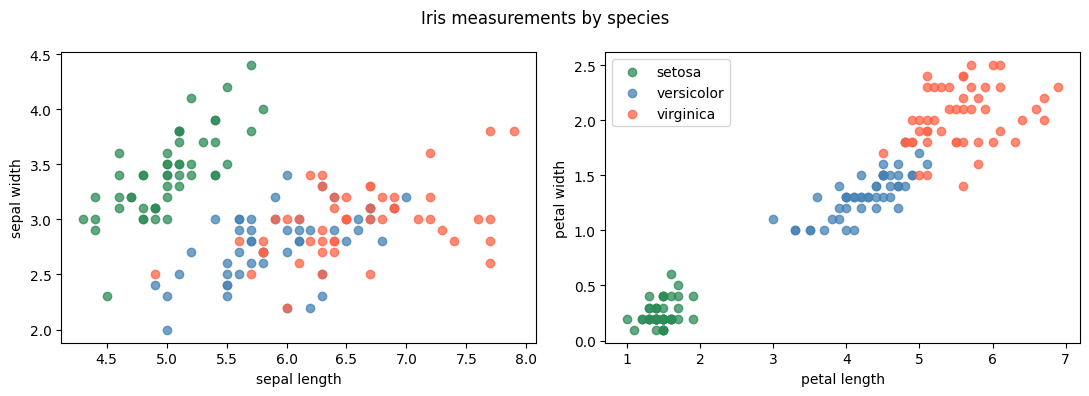

In [2]:
# how separable are the species?
SPECIES = sorted(df['species'].unique())
COLORS = {'setosa': 'seagreen', 'versicolor': 'steelblue', 'virginica': 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for sp in SPECIES:
    s = df[df['species'] == sp]
    axes[0].scatter(s['sepal_length'], s['sepal_width'], label=sp,
                    color=COLORS[sp], alpha=0.75)
    axes[1].scatter(s['petal_length'], s['petal_width'], label=sp,
                    color=COLORS[sp], alpha=0.75)
axes[0].set_xlabel('sepal length'); axes[0].set_ylabel('sepal width')
axes[1].set_xlabel('petal length'); axes[1].set_ylabel('petal width')
axes[1].legend()
fig.suptitle('Iris measurements by species')
plt.tight_layout()
plt.show()

Petal measurements separate the species almost cleanly — sepal ones overlap a lot.
Expect the tree to lean on the petal features (it will — see below).

## Step 1 — Grow a full (unpruned) tree

No limits first: let it grow as deep as it wants and watch it **memorise**
the training data.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print('train:', X_train.shape, ' test:', X_test.shape)

full = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f'\ndepth: {full.get_depth()}   leaves: {full.get_n_leaves()}')
print(f'train accuracy: {full.score(X_train, y_train):.3f}  <- perfect = memorised')
print(f'test  accuracy: {full.score(X_test, y_test):.3f}')

train: (105, 4)  test: (45, 4)

depth: 5   leaves: 8
train accuracy: 1.000  <- perfect = memorised
test  accuracy: 0.933


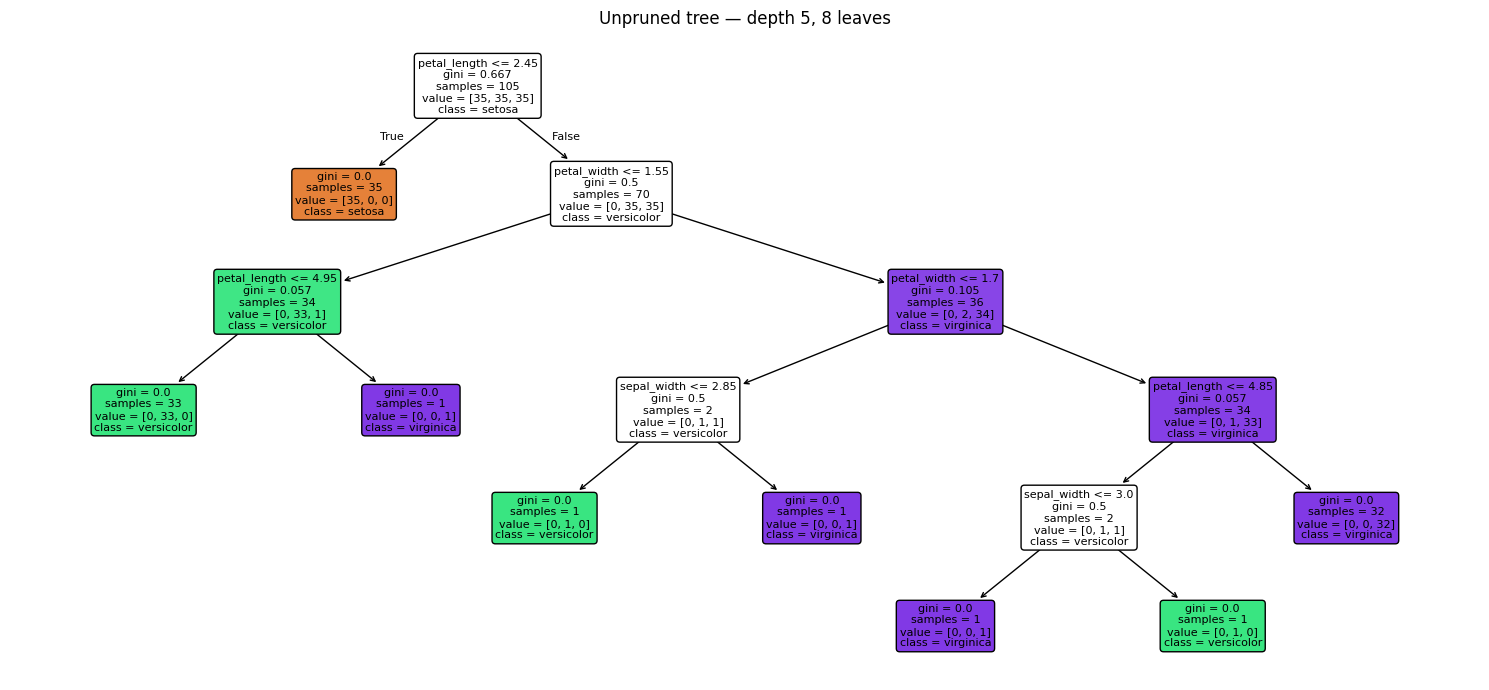

In [4]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 7))
plot_tree(full, feature_names=X.columns, class_names=full.classes_,
          filled=True, rounded=True, fontsize=8)
plt.title(f'Unpruned tree — depth {full.get_depth()}, {full.get_n_leaves()} leaves')
plt.tight_layout()
plt.show()